In [1]:
# ==============================================================================
#                 SEZIONE 1: SETUP, CONFIGURAZIONE E IMPORT
# ==============================================================================
import os
import sys
import json
import glob
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Controllo della GPU
print("Dispositivi TensorFlow disponibili:", tf.config.list_physical_devices())

# --- Gestione di Google Colab e del Progetto ---

# 1. Monta Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Definisci il percorso radice del tuo progetto su Google Drive
PROJECT_ROOT = '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab'

# 3. Aggiungi la cartella del progetto (che contiene 'src') al path di Python
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 4. Importa i tuoi moduli personalizzati (dopo aver aggiunto il path)
from src import data_loader, models, evaluation

# --- Configurazione Specifica della Pipeline ---
# Questa pipeline utilizza il modello con data augmentation SpecAugment integrata.
PIPELINE_NAME = "Pipeline_B_2GRU_SpecAugment"

# Usa la funzione che carica gli MFCC impilati (MFCC+Delta+DeltaDelta)
FEATURE_LOADER_FN = data_loader.load_precomputed_mfcc_stack

# Usa la funzione del modello che ora contiene il layer di augmentation
# (Assumendo che il file `src/models.py` sia stato aggiornato come discusso)
MODEL_CREATOR_FN = models.create_advanced_2d_cnn_3gru_model

# Definisci nomi di file univoci per questo esperimento
MODEL_FILENAME = f"model_{PIPELINE_NAME}.keras"
METADATA_FILENAME = f"model_{PIPELINE_NAME}_metadata.json"

# Definisci percorsi assoluti e robusti usando os.path.join
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data/processed/features_v2")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
CSV_PATH = os.path.join(PROJECT_ROOT, "data/raw/UrbanSound8K.csv")

# Crea la cartella dei modelli se non esiste
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"--- ESECUZIONE PIPELINE: {PIPELINE_NAME} ---")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Features Directory: {FEATURES_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"CSV File Path: {CSV_PATH}")


# ==============================================================================
#                       SEZIONE 2: CARICAMENTO DEI DATI
# ==============================================================================
print("\n[Fase 1/4] Caricamento di tutti i dati pre-processati...")
all_data = {}
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))

# Controllo di sicurezza per verificare che le feature esistano
if not fold_dirs:
    raise FileNotFoundError(f"Nessuna cartella 'fold*' trovata in {FEATURES_DIR}. "
                          f"Assicurati che il percorso sia corretto e che le feature siano state generate.")

for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    print(f"Caricando {fold_name}...")
    X_fold, y_fold = data_loader.collect_fold_data(
        fold_dir, FEATURE_LOADER_FN
    )
    all_data[fold_name] = (X_fold, y_fold)
print("Caricamento dati completato.")

Dispositivi TensorFlow disponibili: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive
--- ESECUZIONE PIPELINE: Pipeline_B_2GRU_SpecAugment ---
Project Root: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab
Features Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/processed/features_v2
Models Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models
CSV File Path: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/raw/UrbanSound8K.csv

[Fase 1/4] Caricamento di tutti i dati pre-processati...
Caricando fold1...
Caricando fold10...
Caricando fold2...
Caricando fold3...
Caricando fold4...
Caricando fold5...
Caricando fold6...
Caricando fold7...
Caricando fold8...
Caricando fold9...
Caricamento dati completato.


In [2]:

# ==============================================================================
#             SEZIONE 3: PREPARAZIONE DATI E ADDESTRAMENTO FINALE
# ==============================================================================
print("\n[Fase 2/4] Preparazione dati e addestramento del modello finale su split 80/20...")

# 1. Creazione dello split di training e test
X_train_final, y_train_final, X_test_final, y_test_final = data_loader.get_train_test_split_from_folds(
    all_data,
    meta_file_path=CSV_PATH,
    test_size=0.2,
    random_state=42 # Aggiungi random_state per la riproducibilità
)

# 2. Definizione dei parametri del modello
input_shape = X_train_final[0].shape
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)

# 3. Conversione delle etichette in formato one-hot per la Focal Loss
y_train_one_hot = tf.keras.utils.to_categorical(y_train_final, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_final, num_classes=num_classes)

# 4. Creazione del modello finale (che ora include SpecAugment)
final_model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)
final_model.summary()

# 5. Definizione dei callbacks
#    Aumentiamo la pazienza perché l'augmentation rende l'apprendimento più lento e stabile.
callbacks_list = [
    #EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=8, min_lr=1e-6, verbose=1)
]

# 6. Addestramento del modello
print("\nAvvio addestramento...")
final_history = final_model.fit(
    X_train_final, y_train_one_hot,
    validation_data=(X_test_final, y_test_one_hot),
    epochs=100,  # Aumentiamo le epoche, EarlyStopping gestirà lo stop ottimale
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)




[Fase 2/4] Preparazione dati e addestramento del modello finale su split 80/20...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 173, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spec_augment_layer              │ (None, 40, 173, 3)     │             0 │
│ (SpecAugmentLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 173, 64)    │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 173, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 86, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 86, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 21, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 21, 256)        │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,962 (4.26 MB)

 Trainable params: 1,117,322 (4.26 MB)

 Non-trainable params: 640 (2.50 KB)


Avvio addestramento...
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.2206 - loss: 0.4450 - val_accuracy: 0.3560 - val_loss: 0.3852 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4320 - loss: 0.2950 - val_accuracy: 0.4750 - val_loss: 0.3054 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5376 - loss: 0.2306 - val_accuracy: 0.5445 - val_loss: 0.2598 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5684 - loss: 0.2076 - val_accuracy: 0.5973 - val_loss: 0.1928 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6098 - loss: 0.1811 - val_accuracy: 0.6023 - val_loss: 0.2178 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6479 - loss: 0.1702 - val_accuracy: 0.6335 - val_loss: 0.1848 - learning_rate: 3.0000e-04
Epoch 7/100
217/217 ━━━━━━━


[Fase 3/4] Valutazione del modello finale...
Performance finale sul Test Set:
  - Loss: 0.0743
  - Accuracy: 0.8676

Generazione del report di classificazione e della matrice di confusione...
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

--- Report di Classificazione Dettagliato ---
                  precision    recall  f1-score   support

 air_conditioner       0.75      0.89      0.81       196
        car_horn       0.96      0.92      0.94       159
children_playing       0.82      0.81      0.82       182
        dog_bark       0.87      0.89      0.88       159
        drilling       0.78      0.78      0.78       169
   engine_idling       0.96      0.79      0.87       225
        gun_shot       0.94      0.99      0.96       237
      jackhammer       0.91      0.86      0.88       174
           siren       0.87      0.93      0.90       155
    street_music       0.84      0.80      0.82       142

        accuracy                           0.87      1798
       macro avg      

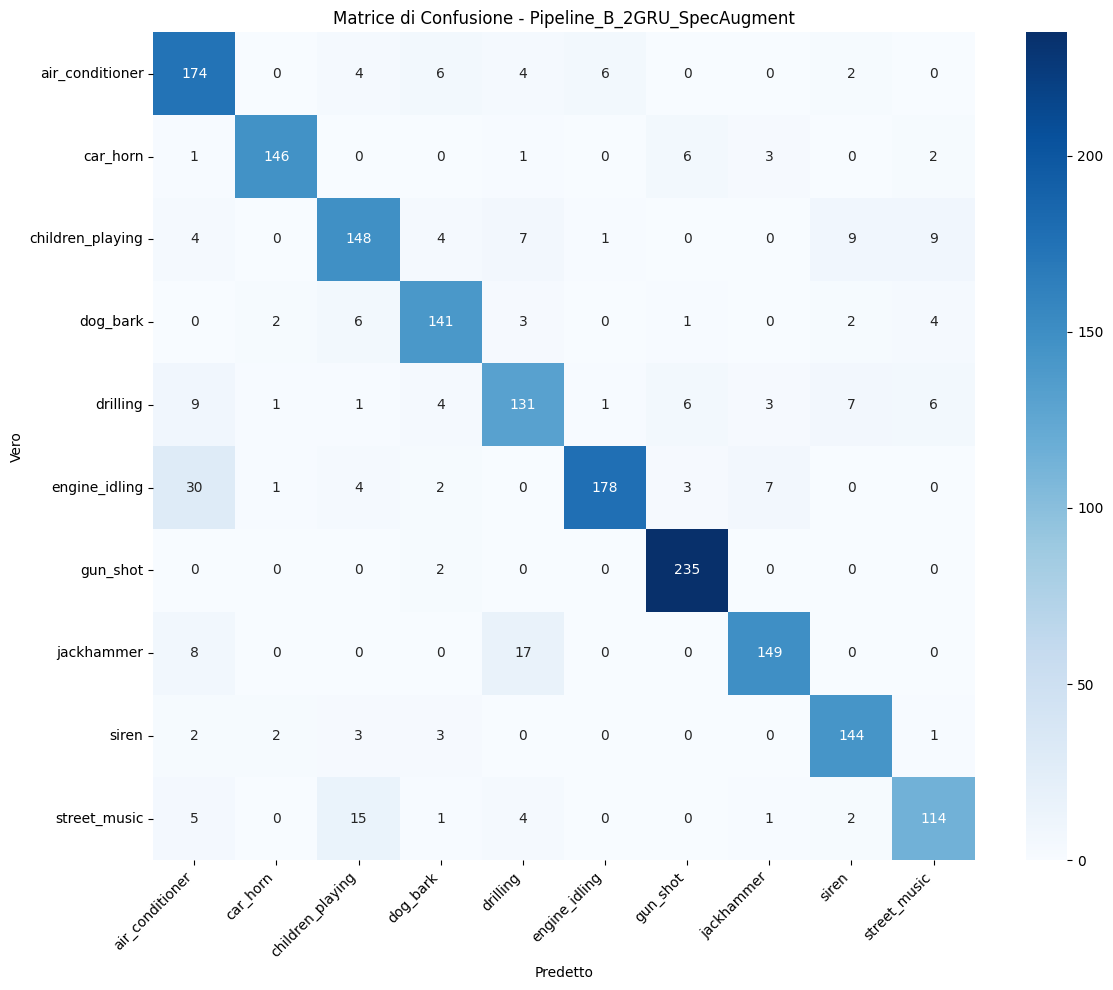


[Fase 4/4] Salvataggio del modello e dei metadati...
Modello salvato in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_Pipeline_B_2GRU_SpecAugment.keras
Metadati salvati in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_Pipeline_B_2GRU_SpecAugment_metadata.json

--- ESECUZIONE COMPLETATA ---


In [3]:
# ==============================================================================
#           SEZIONE 4: VALUTAZIONE DETTAGLIATA, VISUALIZZAZIONE E SALVATAGGIO
# ==============================================================================
print("\n[Fase 3/4] Valutazione del modello finale...")

# 1. Valutazione di base (Loss e Accuracy)
#    Il layer di augmentation si disattiva automaticamente durante .evaluate()
final_loss, final_accuracy = final_model.evaluate(X_test_final, y_test_one_hot, verbose=0)
print(f"Performance finale sul Test Set:")
print(f"  - Loss: {final_loss:.4f}")
print(f"  - Accuracy: {final_accuracy:.4f}\n")

# 2. Ottieni le predizioni per report e matrice di confusione
#    Anche .predict() disattiva l'augmentation.
print("Generazione del report di classificazione e della matrice di confusione...")
y_pred_probs = final_model.predict(X_test_final)
y_pred_final = np.argmax(y_pred_probs, axis=1) # Converte probabilità in etichette intere

# 3. Stampa del Classification Report
print("\n--- Report di Classificazione Dettagliato ---")
print(classification_report(y_test_final, y_pred_final, target_names=class_names))

# 4. Generazione e Visualizzazione della Matrice di Confusione
print("\n--- Matrice di Confusione ---")
conf_matrix = confusion_matrix(y_test_final, y_pred_final)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice di Confusione - {PIPELINE_NAME}')
plt.xlabel('Predetto')
plt.ylabel('Vero')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Salvataggio del modello e dei metadati ---
print("\n[Fase 4/4] Salvataggio del modello e dei metadati...")

# 5. Salva il modello finale
#    Il formato .keras gestisce correttamente i layer custom grazie a get_config()
model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)
final_model.save(model_path)
print(f"Modello salvato in: {model_path}")

# 6. Salva i metadati (con correzioni per evitare errori di tipo JSON)
new_model_architecture_name = "Advanced 2D-CNN + 2xBiGRU with SpecAugment"

metadata = {
    "pipeline_name": PIPELINE_NAME,
    "model_architecture": new_model_architecture_name,
    "model_filename": MODEL_FILENAME,
    "input_shape": list(input_shape),             # Converti tupla in lista
    "num_classes": num_classes,
    "class_names": class_names,
    "final_test_performance": {
        "accuracy": float(final_accuracy),        # Converti tipo NumPy in float
        "loss": float(final_loss)                 # Converti tipo NumPy in float
    }
}
metadata_path = os.path.join(MODELS_DIR, METADATA_FILENAME)
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"Metadati salvati in: {metadata_path}")

print("\n--- ESECUZIONE COMPLETATA ---")